# Indian Job Market Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data Loading & Overview

In [2]:
# Load the datasetdf = pd.read_csv('cleaned_job_dataset_ready.csv')

# Check dataset dimensions (rows and columns)
print("Dataset Shape (Rows, Columns):")
print(df.shape)

# View the first 3 rows to understand the structure
print("\nFirst 3 rows of the dataset:")
display(df.head(3))

Dataset Shape (Rows, Columns):
(97664, 34)

First 3 rows of the dataset:


,title,jobid,currency,jobuploaded,companyname,tagsandskills,experience,salary,location,companyid,...,power_bi_flag,tableau_flag,aws_flag,java_flag,sap_flag,css_flag,javascript_flag,is_salary_disclosed,mid_salary,primary_location
0,Sr. Hr Recruiter (Non It),2.709250e+11,INR,6 Days Ago,Orion,"Communication,Manpower,Staffing,Convincing Pow...",2-4 Yrs,2-4 Lacs PA,Kolkata(Chinar Park),645563,...,0,0,0,0,0,0,0,True,300000.0,Kolkata(Chinar Park)
1,Fire And Safety Officer,2.709250e+11,INR,6 Days Ago,"Apollo Hospitals International Limited, Ahmedabad","Safety Officer Activities,Fire Protection,Fire...",6-11 Yrs,3-5 Lacs PA,"Gandhinagar, Ahmedabad",14072,...,0,0,0,0,0,0,0,True,400000.0,Gandhinagar
2,Opening For Performance Marketing - Chennai,2.709250e+11,INR,6 Days Ago,TVS Credit Services Ltd,"Performance Marketing,User Acquisition,growth ...",12-18 Yrs,Not disclosed,Chennai,1324750,...,0,0,0,0,0,0,0,False,NaN,Chennai


# Exploratory Data Analysis

In [3]:
top_locations = df['primary_location'].value_counts().head(10)

# Top 10 Job Locations

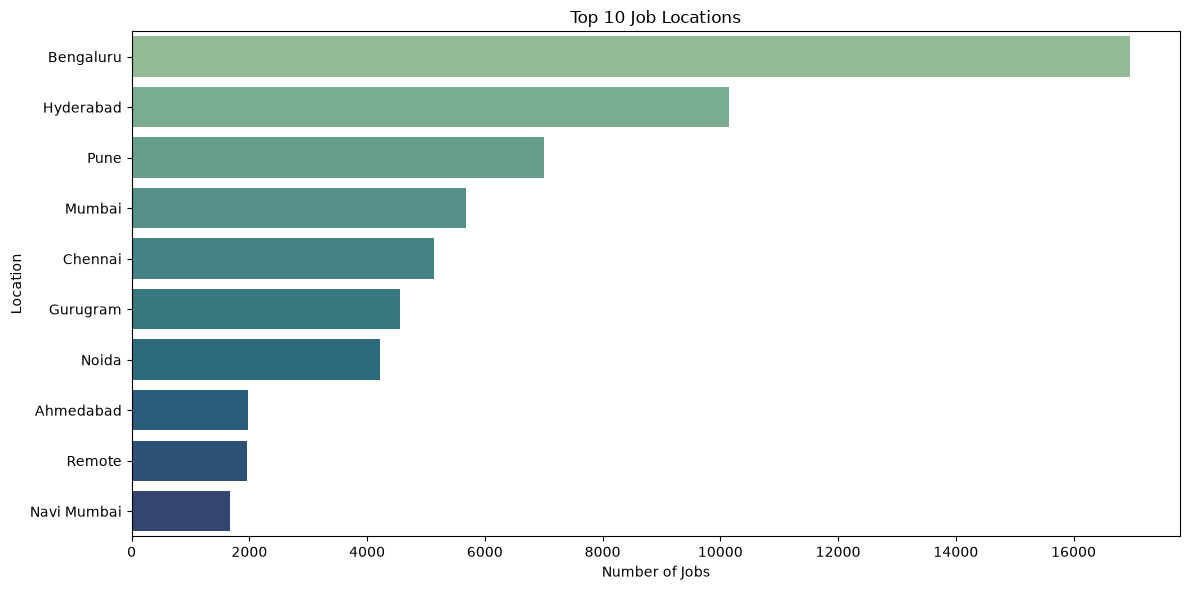

In [4]:
# Find top 10 primary locations with the highest number of job postings
plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_locations.values, 
    y=top_locations.index, 
    hue=top_locations.index, 
    palette="crest", 
    legend=False
)
plt.title("Top 10 Job Locations")
plt.xlabel("Number of Jobs")
plt.ylabel("Location")
plt.tight_layout()
plt.show()

### Salary Analysis

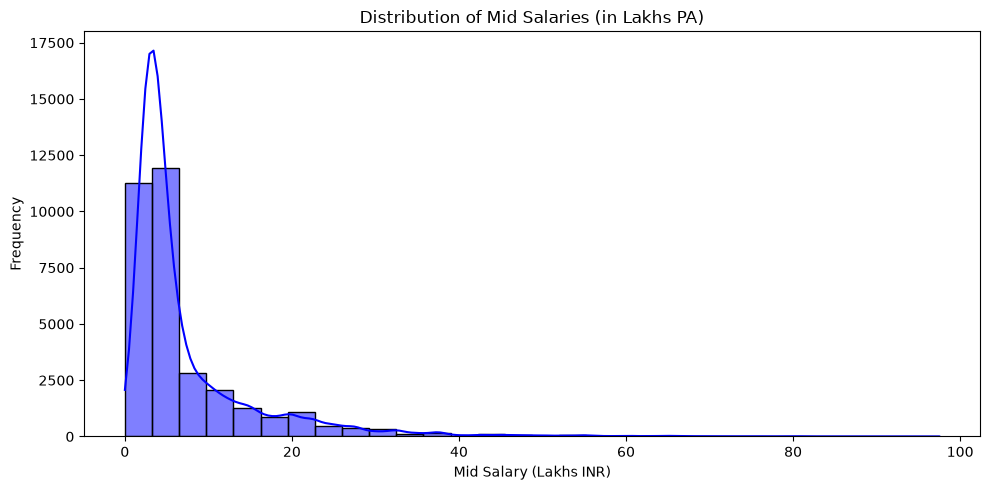

In [5]:
# Histogram: Distribution of Mid Salaries
plt.figure(figsize=(10, 5))

# Filter data for valid salaries
salary_plot = df[
    (df['mid_salary'] > 0) & 
    (df['mid_salary'] <= 10000000)
].copy()

sns.histplot(
    data=salary_plot,
    x=salary_plot['mid_salary'] / 100000,  # Converting salary to Lakhs PA
    bins=30,
    kde=True,
    color='blue'
)

plt.title("Distribution of Mid Salaries (in Lakhs PA)")
plt.xlabel("Mid Salary (Lakhs INR)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

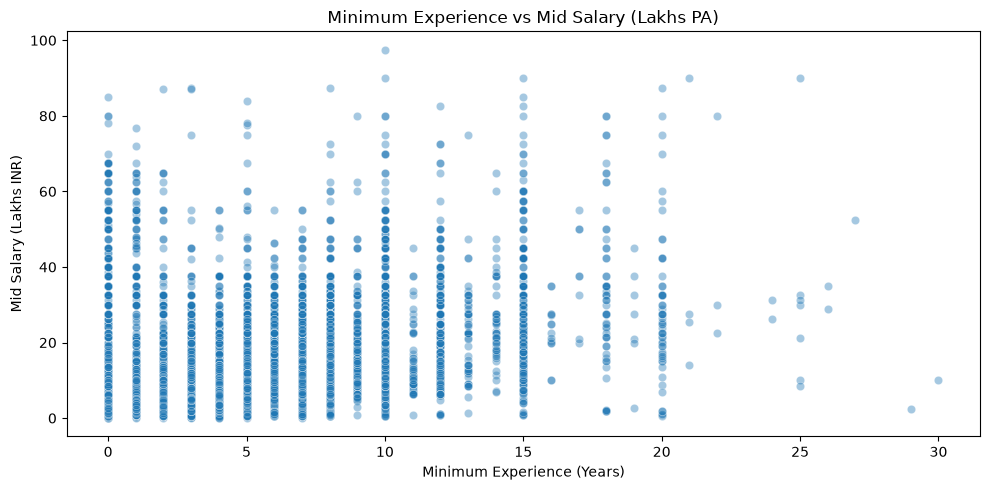

In [6]:
plt.figure(figsize=(10, 5))

plot_df = df[
    (df['mid_salary'] > 0) &
    (df['mid_salary'] <= 10000000)
].copy()

sns.scatterplot(
    data=plot_df,
    x='minimumexperience',
    y=plot_df['mid_salary'] / 100000,
    alpha=0.4
)

plt.title("Minimum Experience vs Mid Salary (Lakhs PA)")
plt.xlabel("Minimum Experience (Years)")
plt.ylabel("Mid Salary (Lakhs INR)")
plt.tight_layout()
plt.show()

# SQL Data Analysis & Business Insights

Loading the processed dataset into an in-memory SQLite database to extract key market trends, salary distributions, and skill demand via structured SQL queries.

In [7]:
import sqlite3
import pandas as pd

df = pd.read_csv("cleaned_job_dataset_ready.csv")
conn = sqlite3.connect(":memory:")
df.to_sql("jobs", conn, index=False, if_exists="replace")

print("Database connection established and table 'jobs' created successfully!")

Database connection established and table 'jobs' created successfully!


In [8]:
# Question: Which are the top 10 locations with the highest number of job openings?
query_1 = """
SELECT 
    primary_location, 
    COUNT(jobid) AS total_jobs
FROM 
    jobs
GROUP BY 
    primary_location
ORDER BY 
    total_jobs DESC
LIMIT 10;
"""

df_res_1 = pd.read_sql(query_1, conn)
print(df_res_1)

  primary_location  total_jobs
0        Bengaluru       16960
1        Hyderabad       10140
2             Pune        7003
3           Mumbai        5677
4          Chennai        5136
5         Gurugram        4559
6            Noida        4213
7        Ahmedabad        1979
8           Remote        1952
9      Navi Mumbai        1673


In [9]:
# Question: What is the average salary breakdown across different minimum experience levels?
query_2 = """
SELECT 
    minimumexperience, 
    ROUND(AVG(average_salary_lacs), 2) AS avg_salary_lacs,
    COUNT(*) AS job_count
FROM 
    jobs
WHERE 
    average_salary_lacs IS NOT NULL
GROUP BY 
    minimumexperience
ORDER BY 
    minimumexperience;
"""

df_res_2 = pd.read_sql(query_2, conn)
print(df_res_2)

    minimumexperience  avg_salary_lacs  job_count
0                   0             6.45       7431
1                   1             4.89       7330
2                   2             5.54       4651
3                   3             7.23       3654
4                   4             9.11       2140
5                   5            11.60       2837
6                   6            15.31       1186
7                   7            15.12        879
8                   8            16.69       1009
9                   9            17.64        222
10                 10            18.27       1138
11                 11            15.41         56
12                 12            23.00        320
13                 13            22.68         55
14                 14            26.25         49
15                 15            26.54        295
16                 16            24.32         15
17                 17            37.69          9
18                 18            31.89         58


In [10]:
# Question: Which companies offer the highest average salary for jobs requiring at least 2 years of minimum experience?
query_3 = """
SELECT 
    companyname,
    primary_location,
    COUNT(jobid) AS total_openings,
    ROUND(AVG(average_salary_lacs), 2) AS avg_salary_lacs
FROM 
    jobs
WHERE 
    minimumexperience >= 2 AND average_salary_lacs IS NOT NULL
GROUP BY 
    companyname, primary_location
HAVING 
    COUNT(jobid) >= 2
ORDER BY 
    avg_salary_lacs DESC
LIMIT 10;
"""

df_res_3 = pd.read_sql(query_3, conn)
print(df_res_3)

                                    companyname primary_location  \
0                               Muthoot Finance        Bengaluru   
1                                 EMC HOSPITALS         Amritsar   
2                    Kansal Corporate Solutions           Remote   
3                                          Fsnl           Bhilai   
4                                 Rama Medicare            Noida   
5                  AXIA Global Talent Solutions          Chennai   
6  Rohilkhand Medical College & Hospital (RMCH)     Shahjahanpur   
7                               Purechase India      Navi Mumbai   
8                 Integrated Personnel Services         Gurugram   
9                       De Corporate Consulting        Hyderabad   

   total_openings  avg_salary_lacs  
0               2           130.31  
1               3            66.67  
2               2            63.75  
3               2            60.00  
4               2            58.13  
5               2            

In [11]:
# Question: Which are the top 3 highest-paying companies per location using window functions?
query_4 = """
WITH RankedCompanySalary AS (
    SELECT 
        primary_location,
        companyname,
        COUNT(jobid) AS open_positions,
        ROUND(AVG(average_salary_lacs), 2) AS avg_salary,
        DENSE_RANK() OVER(PARTITION BY primary_location ORDER BY AVG(average_salary_lacs) DESC) as salary_rank
    FROM 
        jobs
    WHERE 
        average_salary_lacs IS NOT NULL
    GROUP BY 
        primary_location, companyname
    HAVING 
        COUNT(jobid) >= 2
)
SELECT 
    primary_location,
    companyname,
    open_positions,
    avg_salary
FROM 
    RankedCompanySalary
WHERE 
    salary_rank <= 3;
"""

df_res_4 = pd.read_sql(query_4, conn)
print(df_res_4.head(15))

                   primary_location  \
0                          Achampet   
1                          Adilabad   
2                          Adilabad   
3                          Agartala   
4                              Agra   
5                              Agra   
6                              Agra   
7               Agra(Sanjay Place )   
8                         Ahmedabad   
9                         Ahmedabad   
10                        Ahmedabad   
11  Ahmedabad(Ahmedabad Cantonment)   
12            Ahmedabad(Chandkheda)   
13     Ahmedabad(Gidc Estate Vatva)   
14      Ahmedabad(Iscon Ambli Road)   

                                  companyname  open_positions  avg_salary  
0                                   Sita Corp               2        5.44  
1   Purview India Consulting And Services Llp               3       19.58  
2                                   Sita Corp               2        5.44  
3                           Sapna Hr Services               2       60.

In [12]:
# Question: How does the presence of key technical skills like Python, SQL, and AWS impact average salaries?
query_5 = """
SELECT 
    'Python' AS skill,
    SUM(python_flag) AS total_jobs_with_skill,
    ROUND(AVG(CASE WHEN python_flag = 1 THEN average_salary_lacs END), 2) AS avg_salary_with_skill,
    ROUND(AVG(CASE WHEN python_flag = 0 THEN average_salary_lacs END), 2) AS avg_salary_without_skill
FROM jobs
UNION ALL
SELECT 
    'SQL' AS skill,
    SUM(sql_flag) AS total_jobs_with_skill,
    ROUND(AVG(CASE WHEN sql_flag = 1 THEN average_salary_lacs END), 2) AS avg_salary_with_skill,
    ROUND(AVG(CASE WHEN sql_flag = 0 THEN average_salary_lacs END), 2) AS avg_salary_without_skill
FROM jobs
UNION ALL
SELECT 
    'AWS' AS skill,
    SUM(aws_flag) AS total_jobs_with_skill,
    ROUND(AVG(CASE WHEN aws_flag = 1 THEN average_salary_lacs END), 2) AS avg_salary_with_skill,
    ROUND(AVG(CASE WHEN aws_flag = 0 THEN average_salary_lacs END), 2) AS avg_salary_without_skill
FROM jobs;
"""

df_res_5 = pd.read_sql(query_5, conn)
print(df_res_5)

    skill  total_jobs_with_skill  avg_salary_with_skill  \
0  Python                   5934                  18.24   
1     SQL                   6253                  16.05   
2     AWS                   2515                  17.17   

   avg_salary_without_skill  
0                      8.28  
1                      8.29  
2                      8.35  


# Key Insights

* **Job Hub Concentration:** EDA and SQL analysis reveal that job openings are heavily concentrated in major metropolitan hubs like Bangalore, Pune, Hyderabad, and NCR.
* **Experience Scaling:** Salary packages scale consistently with increasing minimum experience requirements, showing a structured growth trajectory from entry-level to senior roles.
* **Skill Demand & Premium:** Technical roles requiring modern stacks (such as Python, SQL, and AWS) command noticeable salary premiums compared to general job postings.
* **Top-Paying Employers:** A selective group of companies offers the highest average salary brackets, specifically for roles requiring multi-skilled profiles and minimum 2+ years of experience.

# Conclusion

* **Overall Market Health:** The combination of exploratory data analysis and structured SQL queries indicates a robust, skill-driven job market with clear hiring patterns, distinct regional hubs, and transparent salary disclosures across tech sectors.